In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parents[0]))

In [2]:
import rompy as rp
import numpy as np
import scipy.interpolate as si
import matplotlib.pyplot as plt

from surrogw.modules.constants import *
from surrogw.dataset.loader import DataLoader
from surrogw.dataset.gen import GWDataGen

plt.rcParams.update({'figure.max_open_warning': 0})

### Load training data

In [3]:
data = DataLoader(filename='training_data.hdf5')
print('Loaded data: n_waveforms=', data.n_waveforms, 'n_amp_nodes=', data.n_amp_nodes)

Loaded data: n_waveforms= 3600 n_amp_nodes= 200


### Trapezoidal weights for arbitrary nodes

In [4]:
def trapezoidal_weights(x):
    x = np.asarray(x)
    dx = np.diff(x)
    w = np.empty_like(x)
    if len(x) == 1:
        return np.array([1.0])
    w[0] = dx[0]/2.0
    w[-1] = dx[-1]/2.0
    if len(x) > 2:
        w[1:-1] = 0.5*(dx[:-1] + dx[1:])
    return w

### Build RB + EIM for amplitude 

In [5]:
freq_amp = data.sparse_freq_amp
w_amp = trapezoidal_weights(freq_amp)
int_amp = rp.Integration(nodes=freq_amp, weights=w_amp)
training_amp = np.asarray(data.A_mat).T  # shape is (n_waveforms, n_freqs)
rb_amp = rp.ReducedBasis(int_amp)
rb_amp.make(training_space=training_amp, index_seed=0, tol=1e-8, verbose=True, timer=True)
eim_amp = rp.EmpiricalInterpolant(rb_amp.basis, verbose=True)
print('Amplitude RB modes =', rb_amp.basis.shape, 'EIM nodes =', len(eim_amp.indices))

Step      Error
1:   0.9998088418889923
2:   0.03308539424774981
3:   0.011168856326852605
4:   0.005395163395839231
5:   0.0022142016235678907
6:   0.001255017043256923
7:   0.0005781240805864396
8:   0.00032644250081403925
9:   0.00022379262446725612
10:   0.00012114972565957505
11:   9.333934161592783e-05
12:   6.142241032458529e-05
13:   3.477253542238934e-05
14:   1.9033655797140447e-05
15:   1.1003757417915594e-05
16:   8.505325709506906e-06
17:   6.249288716952961e-06
18:   4.385026003639325e-06
19:   3.2232846294277806e-06
20:   3.032439130468134e-06
21:   1.7724132937990689e-06
22:   1.6925108172749503e-06
23:   1.3826385478754588e-06
24:   1.1555109907801508e-06
25:   1.0053121296538237e-06
26:   7.54785239420741e-07
27:   6.940999066618048e-07
28:   6.085912767073154e-07
29:   5.400790610288198e-07
30:   5.295127420978929e-07
31:   5.135841875114622e-07
32:   4.828953331648123e-07
33:   4.807896704095427e-07
34:   4.5866104336766966e-07
35:   4.534795664534741e-07
36:   4.40

### Build RB + EIM for phase (center each waveform by its initial phase) 

In [6]:
freq_phase = data.sparse_freq_phase
w_phase = trapezoidal_weights(freq_phase)
int_phase = rp.Integration(nodes=freq_phase, weights=w_phase)
training_phase = np.asarray(data.Phi_mat).T
# Remove each waveform's initial phase to make phases smooth across params
training_phase_centered = training_phase - training_phase[:,0][:,None]
rb_phase = rp.ReducedBasis(int_phase)
rb_phase.make(training_space=training_phase_centered, index_seed=0, tol=1e-8, verbose=True, timer=True)
eim_phase = rp.EmpiricalInterpolant(rb_phase.basis, verbose=True)
print('Phase RB modes =', rb_phase.basis.shape, 'EIM nodes =', len(eim_phase.indices))

Step      Error
1:   366686318.0140396
2:   165454.01403957605
3:   5503.3755241036415
4:   939.7034025341272
5:   202.73164904117584
6:   162.9116117656231
7:   62.721658170223236
>>> Warning(Index already selected): Exiting greedy algorithm.
('\nElapsed time =', 0.03655719757080078)
Step      Nodes
1:         154
2:         45
3:         100
4:         198
5:         199
6:         177
7:         190
Phase RB modes = (7, 200) EIM nodes = 7


# Build parameter-space interpolants for EIM node values and amp norms

In [7]:
q_unique = np.unique(data.param_grid_q)
chi_unique = np.unique(data.param_grid_chi)
grid_shape = data.param_grid_q.shape
n_waveforms = training_amp.shape[0]

### Amplitude: collect node values across training set for each EIM index

In [8]:
amp_node_vals = training_amp[:, eim_amp.indices]  # (n_waveforms, n_eim)
phase_node_vals = training_phase_centered[:, eim_phase.indices]

### Reshape into (n_chi, n_q) grids and build RectBivariateSpline for each node

In [9]:
amp_node_interps = []
for k in range(amp_node_vals.shape[1]):
    z = amp_node_vals[:, k].reshape(grid_shape)
    amp_node_interps.append(si.RectBivariateSpline(chi_unique, q_unique, z))

phase_node_interps = []
for k in range(phase_node_vals.shape[1]):
    z = phase_node_vals[:, k].reshape(grid_shape)
    phase_node_interps.append(si.RectBivariateSpline(chi_unique, q_unique, z))

### Amplitude norm interpolant (amp_norms stored per snapshot)

In [10]:
amp_norms_grid = np.asarray(data.amp_norms).reshape(grid_shape)
amp_norm_interp = si.RectBivariateSpline(chi_unique, q_unique, amp_norms_grid)

# Evaluate

### Choose a random training sample to validate surrogate reconstruction

In [11]:
# rand_idx = np.random.choice(n_waveforms)
q0 = 2.76
chi0 = 0.65
print('Validating on training sample with', 'q=', q0, 'chi=', chi0)

Validating on training sample with q= 2.76 chi= 0.65


### Evaluate node interpolants at (chi0, q0)

In [12]:
amp_nodes_pred = np.array([interp(chi0, q0)[0,0] for interp in amp_node_interps])
phase_nodes_pred = np.array([interp(chi0, q0)[0,0] for interp in phase_node_interps])
amp_norm_pred = float(amp_norm_interp(chi0, q0)[0,0])

#### Reconstruct full waveform from EIM matrix B (B shape (Nbasis, Nquads))

In [13]:
amp_rec = amp_nodes_pred.dot(eim_amp.B)
phase_rec = phase_nodes_pred.dot(eim_phase.B)
amp_rec_scaled = amp_rec * amp_norm_pred

#### Retrieve true data for comparison (true amplitude stored normalized in A_mat)

In [14]:
params = {'q': q0, 'chi': chi0}
normalized_amp, norm, true_phase, freqs_masked, params = GWDataGen.process_waveform(params, f_lower, delta_t, window_type, LAL_taper_method, epsilon, num_extrema_start, num_extrema_end, f_min_mask, f_max_mask)

true_amp = normalized_amp * norm

amp_spline = si.CubicSpline(freqs_masked, true_amp)
phase_spline = si.CubicSpline(freqs_masked, true_phase)

true_amp = amp_spline(data.sparse_freq_amp)
true_phase = phase_spline(data.sparse_freq_phase)

In [15]:
true_phase_centered = true_phase - true_phase[0]

# phase_rec_full = phase_rec + true_phase[0]

### Metrics

In [16]:
amp_err = np.linalg.norm(true_amp - amp_rec_scaled) / np.linalg.norm(true_amp)
phase_err = np.linalg.norm(true_phase_centered - phase_rec) / max(1e-12, np.linalg.norm(true_phase_centered))
print(f'Relative L2 error (amp) = {amp_err:.3e}, (phase) = {phase_err:.3e}')

Relative L2 error (amp) = 2.785e-04, (phase) = 5.856e-04


#### Plots

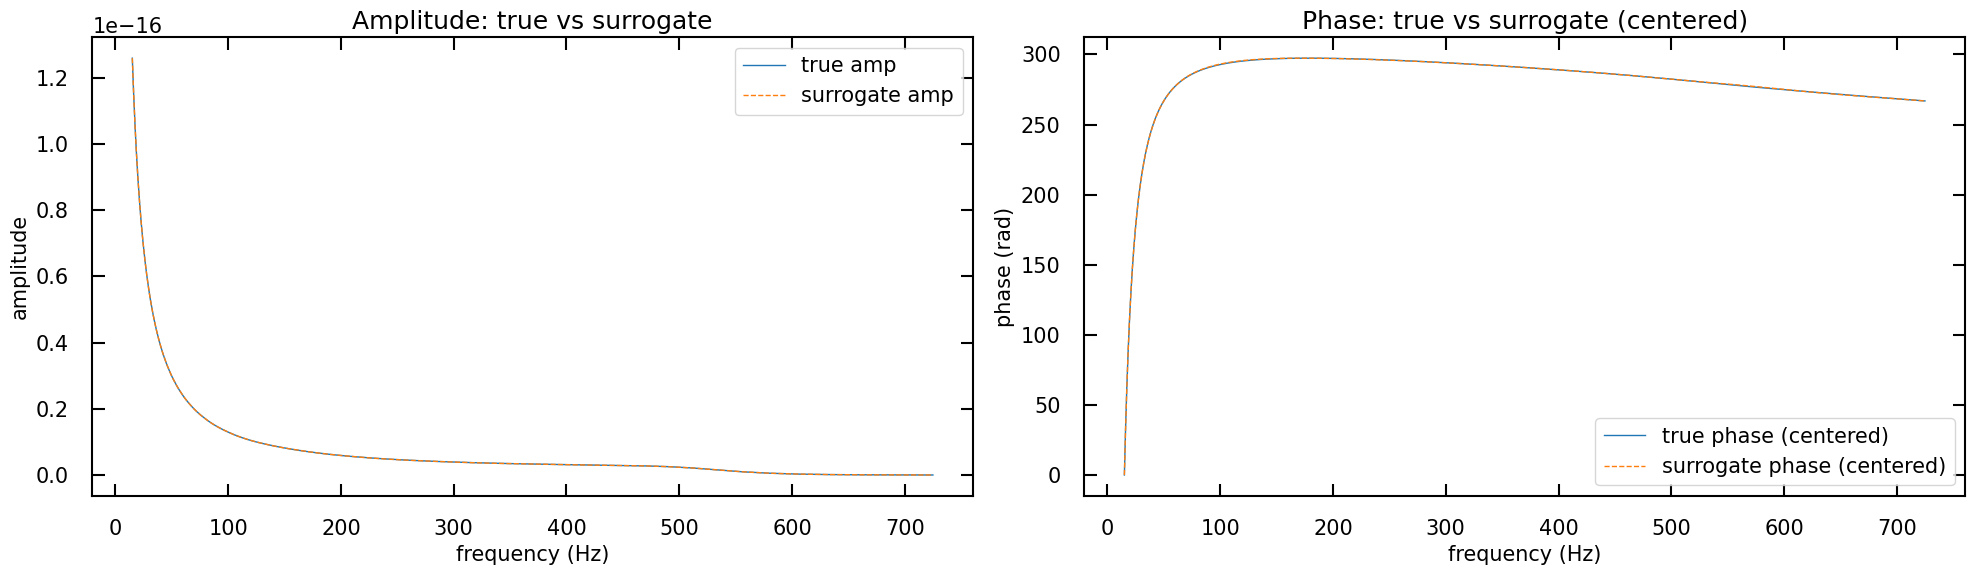

In [17]:
plt.figure(figsize=(20,6))
plt.subplot(1,2,1)
plt.plot(freq_amp, true_amp, label='true amp')
plt.plot(freq_amp, amp_rec_scaled, '--', label='surrogate amp')
plt.xlabel('frequency (Hz)')
plt.ylabel('amplitude')
plt.title('Amplitude: true vs surrogate')
plt.legend()

plt.subplot(1,2,2)
plt.plot(freq_phase, true_phase_centered, label='true phase (centered)')
plt.plot(freq_phase, phase_rec, '--', label='surrogate phase (centered)')
plt.xlabel('frequency (Hz)')
plt.ylabel('phase (rad)')
plt.title('Phase: true vs surrogate (centered)')
plt.legend()
plt.tight_layout()
plt.show()

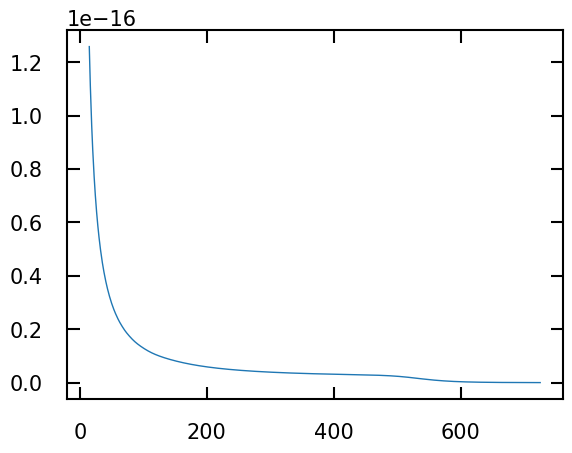

In [18]:
plt.plot(freqs_masked, normalized_amp * norm)